In [1]:
import sys
from pathlib import Path

# notebook normally runs with cwd at the `analysis/` folder — add parent (project root)
project_root = Path.cwd().resolve().parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import joblib
import xgboost as xgb
import lightgbm as lgb
import optuna
from scipy.stats import randint, uniform
from datetime import timedelta
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.ensemble import RandomForestRegressor

# use absolute imports in notebook (project root was added to sys.path above)
from models.data_manipulator import INRDataManipulation
from models.training_plot import INRModelPlot
from models.training_model import ModelTrainer

import warnings
warnings.filterwarnings("ignore")

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


generated
1    76
0    73
Name: count, dtype: int64
Features a serem analisadas: ['dose_semanal', 'generated', 'weekofyear', 'month', 'inr_lag_1', 'inr_lag_2', 'inr_lag_3', 'inr_lag_4', 'inr_roll_mean_2', 'inr_roll_mean_4']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   test_date        149 non-null    datetime64[ns]
 1   dose_semanal     149 non-null    float64       
 2   inr              149 non-null    float64       
 3   inr_diff         149 non-null    float64       
 4   low_range        149 non-null    float64       
 5   high_range       149 non-null    float64       
 6   generated        149 non-null    int64         
 7   weekofyear       149 non-null    int64         
 8   month            149 non-null    int64         
 9   year             149 non-null    int64         
 10  inr_lag_1        149 non-null 

,test_date,dose_semanal,inr,inr_diff,low_range,high_range,generated,weekofyear,month,year,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,2022-08-24,97.5,3.024,0.094,2.5,3.5,1,34,8,2022,2.930,2.891,2.840,2.940,2.9105,2.90025
1,2022-08-31,97.5,3.107,0.082,2.5,3.5,1,35,8,2022,3.024,2.930,2.891,2.840,2.9770,2.92125
2,2022-09-07,97.5,3.189,0.083,2.5,3.5,1,36,9,2022,3.107,3.024,2.930,2.891,3.0655,2.98800
3,2022-09-14,97.5,3.260,0.071,2.5,3.5,0,37,9,2022,3.189,3.107,3.024,2.930,3.1480,3.06250
4,2022-09-21,97.5,3.329,0.069,2.5,3.5,1,38,9,2022,3.260,3.189,3.107,3.024,3.2245,3.14500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,2025-05-28,75.0,2.760,-0.476,2.5,3.5,0,22,5,2025,3.236,3.870,2.957,1.740,3.5530,2.95075
145,2025-06-04,75.0,2.765,0.005,2.5,3.5,1,23,6,2025,2.760,3.236,3.870,2.957,2.9980,3.20575
146,2025-06-11,75.0,2.769,0.004,2.5,3.5,1,24,6,2025,2.765,2.760,3.236,3.870,2.7625,3.15775
147,2025-06-18,75.0,2.773,0.004,2.5,3.5,1,25,6,2025,2.769,2.765,2.760,3.236,2.7670,2.88250


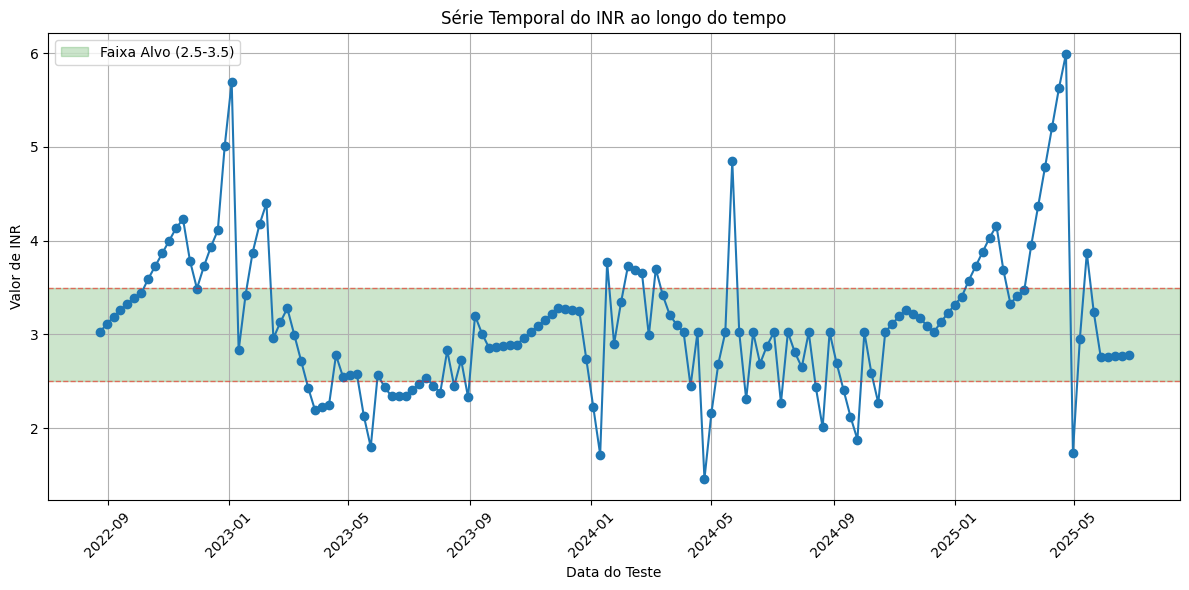

In [11]:
path = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ALEXANDRE JOSE MARTINS BORBOREMA2.xlsx"

diag = INRModelPlot()

paciente = INRDataManipulation(path=path)

data = paciente.get_data_final()

_, features = paciente.get_features()


print(data['generated'].value_counts())
print("Features a serem analisadas:", features)
print(data.info())

display(data)

paciente.plot_inr()

## Predição de INR

In [3]:
TARGET_COL = "inr"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X = data[features].copy()
y = data[TARGET_COL].copy()

display(X.head())
print(X.info())
print(y.head())
print(y.info())

# Separação treino/teste 
n_total = len(data)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
dates_train = data[DATE_COL].iloc[:n_train]
dates_test = data[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals = data['low_range'].iloc[n_train:].values
high_vals = data['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train)}, test={len(X_test)}")

,dose_semanal,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,97.5,1,34,8,2.930,2.891,2.840,2.940,2.9105,2.90025
1,97.5,1,35,8,3.024,2.930,2.891,2.840,2.9770,2.92125
2,97.5,1,36,9,3.107,3.024,2.930,2.891,3.0655,2.98800
3,97.5,0,37,9,3.189,3.107,3.024,2.930,3.1480,3.06250
4,97.5,1,38,9,3.260,3.189,3.107,3.024,3.2245,3.14500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dose_semanal     149 non-null    float64
 1   generated        149 non-null    int64  
 2   weekofyear       149 non-null    int64  
 3   month            149 non-null    int64  
 4   inr_lag_1        149 non-null    float64
 5   inr_lag_2        149 non-null    float64
 6   inr_lag_3        149 non-null    float64
 7   inr_lag_4        149 non-null    float64
 8   inr_roll_mean_2  149 non-null    float64
 9   inr_roll_mean_4  149 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 11.8 KB
None
0    3.024
1    3.107
2    3.189
3    3.260
4    3.329
Name: inr, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 149 entries, 0 to 148
Series name: inr
Non-Null Count  Dtype  
--------------  -----  
149 non-null    float64
dtypes: float64(1)
memory usage: 1.3 KB
None
Ob

In [ ]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

✅ ModelTrainer Inicializado
📊 Shape X_train: (120, 10)
📊 Shape y_train: (120,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42



[I 2026-02-13 03:19:59,627] A new study created in memory with name: xgboost_optimization



🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE

🚀 INICIANDO TREINAMENTO DE TODOS OS MODELOS
Modelos a treinar: ['xgboost', 'lightgbm', 'randomforest', 'elasticnet']
Total de trials: 340

🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: Sem limite segundos



Best trial: 0. Best value: -0.513665:   1%|          | 1/100 [00:03<05:16,  3.20s/it]

[I 2026-02-13 03:20:02,828] Trial 0 finished with value: -0.5136650794479973 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -0.5136650794479973.


Best trial: 1. Best value: -0.499132:   2%|▏         | 2/100 [00:05<04:19,  2.65s/it]

...

[I 2026-02-13 03:22:43,689] Trial 40 finished with value: -0.551943740515305 and parameters: {'alpha': 0.7368884479285521, 'l1_ratio': 0.6080448990696415, 'tol': 0.0008119875079399007, 'selection': 'cyclic'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,690] Trial 42 finished with value: -0.502510420227686 and parameters: {'alpha': 0.4124810297252535, 'l1_ratio': 0.8745476242842047, 'tol': 5.6772088130587624e-05, 'selection': 'cyclic'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,690] Trial 41 finished with value: -0.4035387126975858 and parameters: {'alpha': 0.04405817311710136, 'l1_ratio': 0.5789759961347982, 'tol': 0.0005615167696175592, 'selection': 'random'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,700] Trial 43 finished with value: -0.358657789004791 and parameters: {'alpha': 0.031060414026619073, 'l1_ratio': 0.9961589116460825, 'tol': 0.00011012478565409459, 'selection': 'cyclic'}. Best is 

Best trial: 34. Best value: -0.354712:  92%|█████████▏| 55/60 [00:01<00:00, 59.42it/s]

[I 2026-02-13 03:22:43,716] Trial 47 finished with value: -0.6009091116194337 and parameters: {'alpha': 1.1543852088125308, 'l1_ratio': 0.9895445117823819, 'tol': 0.0001340324346494632, 'selection': 'cyclic'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,718] Trial 48 finished with value: -0.4060760000190587 and parameters: {'alpha': 0.2239041093999538, 'l1_ratio': 0.8829524514777082, 'tol': 5.94714531990803e-05, 'selection': 'cyclic'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,719] Trial 46 finished with value: -0.38943282946029806 and parameters: {'alpha': 0.02677718332314408, 'l1_ratio': 0.9720317390817712, 'tol': 7.357023022669357e-05, 'selection': 'cyclic'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,721] Trial 45 finished with value: -0.5566770014053374 and parameters: {'alpha': 0.5067310579437421, 'l1_ratio': 0.9246586128115067, 'tol': 8.826087170140129e-05, 'selection': 'cyclic'}. Best is t

Best trial: 34. Best value: -0.354712: 100%|██████████| 60/60 [00:01<00:00, 55.34it/s]


[I 2026-02-13 03:22:43,885] Trial 56 finished with value: -0.7684439431713788 and parameters: {'alpha': 0.0030950256588021976, 'l1_ratio': 0.6602829149251814, 'tol': 0.00019782843690185098, 'selection': 'random'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,892] Trial 57 finished with value: -0.4642976610607012 and parameters: {'alpha': 0.019201586241101482, 'l1_ratio': 0.9818007069820398, 'tol': 0.00010444262819243885, 'selection': 'random'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,906] Trial 58 finished with value: -0.8160243261379437 and parameters: {'alpha': 0.0013709380067352353, 'l1_ratio': 0.7533848412146784, 'tol': 0.0006240455040424733, 'selection': 'random'}. Best is trial 34 with value: -0.3547116177564222.
[I 2026-02-13 03:22:43,911] Trial 59 finished with value: -0.3555332793568173 and parameters: {'alpha': 0.05458581596038671, 'l1_ratio': 0.8838520884325971, 'tol': 0.0003171708435272463, 'selection': 'cyclic'}.

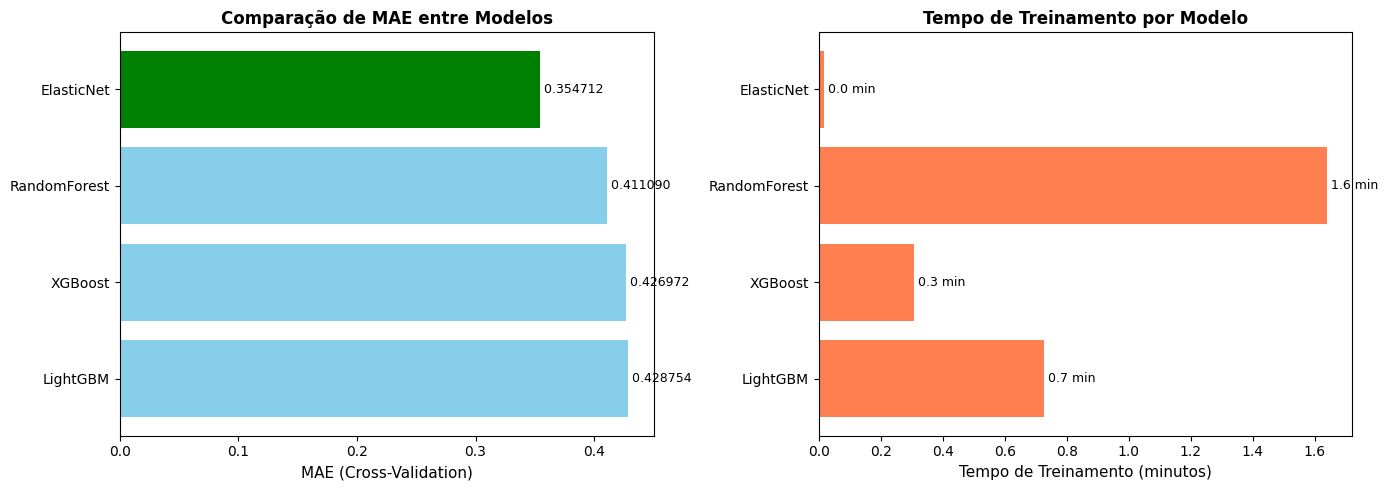

In [ ]:
# ========================================================================
# TREINAR TODOS OS MODELOS DE UMA VEZ
# ========================================================================

print("\n" + "="*70)
print("🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE")
print("="*70)

results = trainer.train_all_models(
    n_trials_dict={
        'xgboost': 100,
        'lightgbm': 100,
        'randomforest': 80,
        'elasticnet': 60
    },
    timeout=None,  # Sem timeout global
    plot_individual=False  # Não plotar cada modelo individualmente
)

# Acessar resultados
xgb_params, xgb_model, xgb_study = results['XGBoost']
lgb_params, lgb_model, lgb_study = results['LightGBM']
rf_params, rf_model, rf_study = results['RandomForest']
elastic_params, elastic_model, elastic_study, elastic_scaler = results['ElasticNet']



🏆 COMPARAÇÃO DE TODOS OS MODELOS

Modelo          MAE (CV)     Tempo (min)  Trials     Data/Hora           
------------------------------------------------------------------------------------------
ElasticNet      0.354712     0.02         60/60      2026-02-13 03:22:43 
RandomForest    0.411090     1.64         80/80      2026-02-13 03:22:42 
XGBoost         0.426972     0.31         100/100     2026-02-13 03:20:18 
LightGBM        0.428754     0.73         100/100     2026-02-13 03:21:02 
------------------------------------------------------------------------------------------

🥇 MELHOR MODELO: ElasticNet
📊 MAE (CV): 0.354712
⏱️ Tempo de treinamento: 0.02 minutos
📈 Melhoria sobre 2º lugar (RandomForest): 13.71%



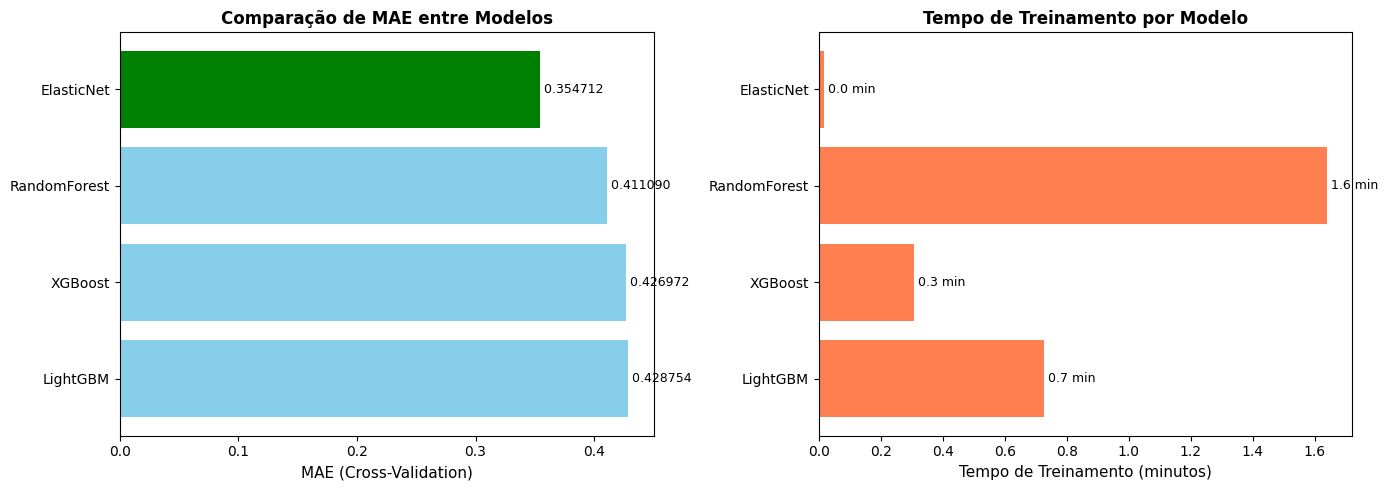


📋 Histórico completo:
     model_name                  timestamp  \
3    ElasticNet 2026-02-13 03:22:43.955503   
2  RandomForest 2026-02-13 03:22:42.143652   
0       XGBoost 2026-02-13 03:20:18.360017   
1      LightGBM 2026-02-13 03:21:02.823153   

                                         best_params  best_cv_mae  \
3  {'alpha': 0.057080735707750865, 'l1_ratio': 0....     0.354712   
2  {'n_estimators': 250, 'max_depth': 6, 'max_fea...     0.411090   
0  {'n_estimators': 900, 'max_depth': 6, 'learnin...     0.426972   
1  {'n_estimators': 700, 'learning_rate': 0.01041...     0.428754   

   training_time_minutes  n_trials  n_completed_trials  n_pruned_trials  
3               0.018123        60                  60                0  
2               1.638719        80                  80                0  
0               0.307190       100                 100                0  
1               0.727344       100                 100                0  

📋 RESUMO DETALHADO DE TREINAM

In [ ]:
# ========================================================================
# ANÁLISES E COMPARAÇÕES
# ========================================================================

# --- Comparar todos os modelos ---
trainer.compare_all_models()

# --- Ver histórico completo ---
history_df = trainer.get_training_history()
print("\n📋 Histórico completo:")
print(history_df)

# --- Resumo detalhado ---
trainer.print_training_summary()

# --- Obter melhor modelo ---
best_name, best_model, best_params, best_mae = trainer.get_best_model()
print(f"\n🏆 Melhor modelo: {best_name}")
print(f"📊 MAE (CV): {best_mae:.6f}")
print(f"🎯 Parâmetros: {best_params}")

## Predição Dose Semanal

In [13]:
features, _ = paciente.get_features()

TARGET_COL = "dose_semanal"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X = data[features].copy()
y = data[TARGET_COL].copy()

display(X.head())
print(X.info())
print(y.head())
print(y.info())

# Separação treino/teste 
n_total = len(data)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
dates_train = data[DATE_COL].iloc[:n_train]
dates_test = data[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals = data['low_range'].iloc[n_train:].values
high_vals = data['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train)}, test={len(X_test)}")

,inr,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,3.024,1,34,8,2.930,2.891,2.840,2.940,2.9105,2.90025
1,3.107,1,35,8,3.024,2.930,2.891,2.840,2.9770,2.92125
2,3.189,1,36,9,3.107,3.024,2.930,2.891,3.0655,2.98800
3,3.260,0,37,9,3.189,3.107,3.024,2.930,3.1480,3.06250
4,3.329,1,38,9,3.260,3.189,3.107,3.024,3.2245,3.14500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inr              149 non-null    float64
 1   generated        149 non-null    int64  
 2   weekofyear       149 non-null    int64  
 3   month            149 non-null    int64  
 4   inr_lag_1        149 non-null    float64
 5   inr_lag_2        149 non-null    float64
 6   inr_lag_3        149 non-null    float64
 7   inr_lag_4        149 non-null    float64
 8   inr_roll_mean_2  149 non-null    float64
 9   inr_roll_mean_4  149 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 11.8 KB
None
0    97.5
1    97.5
2    97.5
3    97.5
4    97.5
Name: dose_semanal, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 149 entries, 0 to 148
Series name: dose_semanal
Non-Null Count  Dtype  
--------------  -----  
149 non-null    float64
dtypes: float64(1)
memory usage: 1

[I 2026-02-13 04:29:38,638] A new study created in memory with name: xgboost_optimization


✅ ModelTrainer Inicializado
📊 Shape X_train: (120, 10)
📊 Shape y_train: (120,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42


🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE

🚀 INICIANDO TREINAMENTO DE TODOS OS MODELOS
Modelos a treinar: ['xgboost', 'lightgbm', 'randomforest', 'elasticnet']
Total de trials: 340

🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: Sem limite segundos



Best trial: 0. Best value: -9.30238:   1%|          | 1/100 [00:02<04:25,  2.68s/it]

[I 2026-02-13 04:29:41,320] Trial 0 finished with value: -9.30238499614028 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -9.30238499614028.


Best trial: 0. Best value: -9.30238:   2%|▏         | 2/100 [00:04<03:44,  2.29s/it]

...

Best trial: 45. Best value: -7.72342:  72%|███████▏  | 43/60 [00:00<00:00, 55.27it/s]

[I 2026-02-13 04:31:43,531] Trial 42 finished with value: -7.924253049489652 and parameters: {'alpha': 6.018367023426647, 'l1_ratio': 0.3434381370888964, 'tol': 5.12780149944012e-05, 'selection': 'random'}. Best is trial 39 with value: -7.7383353341424135.
[I 2026-02-13 04:31:43,532] Trial 41 finished with value: -7.868101986992974 and parameters: {'alpha': 7.0481318940938475, 'l1_ratio': 0.2593680607435855, 'tol': 7.239769634762249e-05, 'selection': 'random'}. Best is trial 39 with value: -7.7383353341424135.
[I 2026-02-13 04:31:43,532] Trial 38 finished with value: -7.799670810252525 and parameters: {'alpha': 6.6016235293619605, 'l1_ratio': 0.19026465334979653, 'tol': 4.139832545080932e-05, 'selection': 'random'}. Best is trial 39 with value: -7.7383353341424135.
[I 2026-02-13 04:31:43,550] Trial 43 finished with value: -7.92488709580619 and parameters: {'alpha': 6.12471460200312, 'l1_ratio': 0.3422595493331487, 'tol': 9.210273282247545e-05, 'selection': 'random'}. Best is trial 39 w

[I 2026-02-13 04:31:43,567] Trial 44 finished with value: -7.743252898689624 and parameters: {'alpha': 6.384456110271208, 'l1_ratio': 0.06659861190044242, 'tol': 0.0009063835176458583, 'selection': 'random'}. Best is trial 39 with value: -7.7383353341424135.
[I 2026-02-13 04:31:43,590] Trial 45 finished with value: -7.7234177506137005 and parameters: {'alpha': 7.2433054938829535, 'l1_ratio': 0.017568179860975662, 'tol': 0.0003794741306045137, 'selection': 'cyclic'}. Best is trial 45 with value: -7.7234177506137005.
[I 2026-02-13 04:31:43,610] Trial 46 finished with value: -7.725961039949422 and parameters: {'alpha': 7.331536852027554, 'l1_ratio': 0.007705211182590717, 'tol': 0.00048715581213490253, 'selection': 'random'}. Best is trial 45 with value: -7.7234177506137005.
[I 2026-02-13 04:31:43,660] Trial 47 finished with value: -7.756124488357854 and parameters: {'alpha': 5.301716232838865, 'l1_ratio': 0.051814956152868595, 'tol': 0.00010868188877318253, 'selection': 'cyclic'}. Best is

Best trial: 45. Best value: -7.72342: 100%|██████████| 60/60 [00:00<00:00, 61.79it/s]


[I 2026-02-13 04:31:43,757] Trial 53 finished with value: -8.21050448800307 and parameters: {'alpha': 1.5772261635419047, 'l1_ratio': 0.11611574072512817, 'tol': 0.0005368632084014741, 'selection': 'cyclic'}. Best is trial 45 with value: -7.7234177506137005.
[I 2026-02-13 04:31:43,757] Trial 55 finished with value: -7.982896064937882 and parameters: {'alpha': 2.5523746844685893, 'l1_ratio': 0.03001981351212533, 'tol': 0.0008850112402313011, 'selection': 'random'}. Best is trial 45 with value: -7.7234177506137005.
[I 2026-02-13 04:31:43,759] Trial 57 finished with value: -8.33590663417223 and parameters: {'alpha': 1.22719682377987, 'l1_ratio': 0.01902284955704399, 'tol': 0.0009161102137183185, 'selection': 'random'}. Best is trial 45 with value: -7.7234177506137005.
[I 2026-02-13 04:31:43,762] Trial 56 finished with value: -8.320290030233236 and parameters: {'alpha': 1.2917129576497157, 'l1_ratio': 0.18967919195107036, 'tol': 0.0009067049360934964, 'selection': 'cyclic'}. Best is trial 

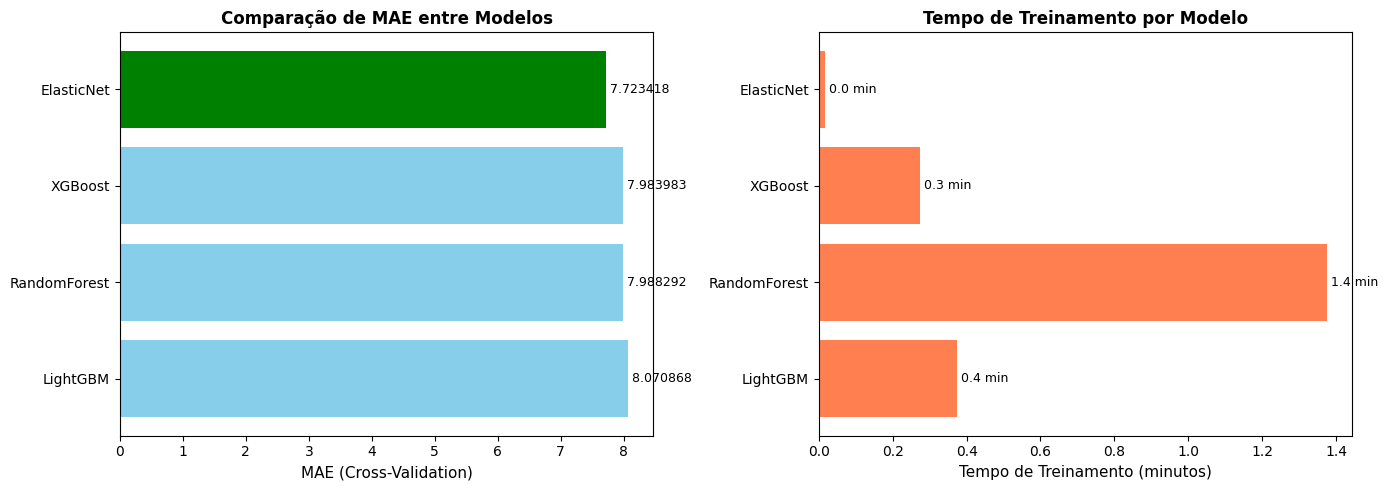

In [ ]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

# ========================================================================
# TREINAR TODOS OS MODELOS DE UMA VEZ
# ========================================================================

print("\n" + "="*70)
print("🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE")
print("="*70)

results = trainer.train_all_models(
    n_trials_dict={
        'xgboost': 100,
        'lightgbm': 100,
        'randomforest': 80,
        'elasticnet': 60
    },
    timeout=None,  # Sem timeout global
    plot_individual=False  # Não plotar cada modelo individualmente
)

# Acessar resultados
xgb_params, xgb_model, xgb_study = results['XGBoost']
lgb_params, lgb_model, lgb_study = results['LightGBM']
rf_params, rf_model, rf_study = results['RandomForest']
elastic_params, elastic_model, elastic_study, elastic_scaler = results['ElasticNet']


🏆 COMPARAÇÃO DE TODOS OS MODELOS

Modelo          MAE (CV)     Tempo (min)  Trials     Data/Hora           
------------------------------------------------------------------------------------------
ElasticNet      7.723418     0.02         60/60      2026-02-13 04:31:43 
XGBoost         7.983983     0.27         100/100     2026-02-13 04:29:55 
RandomForest    7.988292     1.38         80/80      2026-02-13 04:31:41 
LightGBM        8.070868     0.37         100/100     2026-02-13 04:30:18 
------------------------------------------------------------------------------------------

🥇 MELHOR MODELO: ElasticNet
📊 MAE (CV): 7.723418
⏱️ Tempo de treinamento: 0.02 minutos
📈 Melhoria sobre 2º lugar (XGBoost): 3.26%



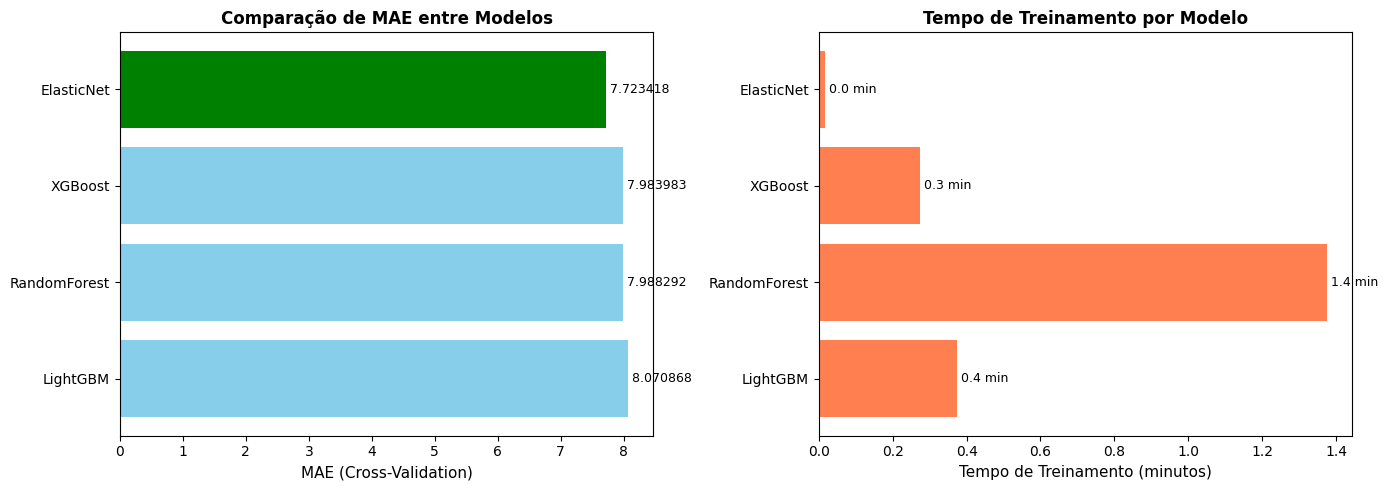


📋 Histórico completo:
     model_name                  timestamp  \
3    ElasticNet 2026-02-13 04:31:43.786620   
0       XGBoost 2026-02-13 04:29:55.183395   
2  RandomForest 2026-02-13 04:31:41.854887   
1      LightGBM 2026-02-13 04:30:18.347825   

                                         best_params  best_cv_mae  \
3  {'alpha': 7.2433054938829535, 'l1_ratio': 0.01...     7.723418   
0  {'n_estimators': 500, 'max_depth': 3, 'learnin...     7.983983   
2  {'n_estimators': 700, 'max_depth': 20, 'max_fe...     7.988292   
1  {'n_estimators': 1000, 'learning_rate': 0.0166...     8.070868   

   training_time_minutes  n_trials  n_completed_trials  n_pruned_trials  
3               0.016230        60                  60                0  
0               0.274581       100                 100                0  
2               1.375039        80                  80                0  
1               0.374478       100                 100                0  

📋 RESUMO DETALHADO DE TREINAM

In [ ]:
# ========================================================================
# ANÁLISES E COMPARAÇÕES
# ========================================================================

# --- Comparar todos os modelos ---
trainer.compare_all_models()

# --- Ver histórico completo ---
history_df = trainer.get_training_history()
print("\n📋 Histórico completo:")
print(history_df)

# --- Resumo detalhado ---
trainer.print_training_summary()

# --- Obter melhor modelo ---
best_name, best_model, best_params, best_mae = trainer.get_best_model()
print(f"\n🏆 Melhor modelo: {best_name}")
print(f"📊 MAE (CV): {best_mae:.6f}")
print(f"🎯 Parâmetros: {best_params}")